In [9]:
import pandas as pd

In [10]:
import os

In [11]:
print(os.path.getsize('../data/features/train_features.csv'))

22720271


In [12]:
training_data = pd.read_csv("../data/features/train_features.csv")
testing_data = pd.read_csv("../data/features/test_features.csv")
rul_df = pd.read_csv('../data/raw/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

In [15]:
training_data.shape

(20631, 61)

In [14]:
testing_data.shape

(13096, 60)

In [16]:
rul_df

,RUL
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117


In [17]:
from sklearn.model_selection import train_test_split

### 1. Train/Validation split

In [35]:
unique_engine_ids = training_data['engine_id'].unique()

In [43]:
unique_engine_ids

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [44]:
engine_id_train, engine_id_val = train_test_split(unique_engine_ids, test_size=0.2, random_state=1234)

In [53]:
print(len(engine_id_train))
print(len(engine_id_val))

80
20


In [56]:
train_split = training_data[training_data['engine_id'].isin(engine_id_train)]
val_split = training_data[training_data['engine_id'].isin(engine_id_val)]

In [58]:
print(train_split.shape)
print(val_split.shape)

(16200, 61)
(4431, 61)


In [61]:
train_split

,engine_id,cycle,op1,op2,op3,sensor2,sensor3,sensor4,sensor7,sensor9,...,sensor17_mean10,sensor17_std10,sensor20_mean5,sensor20_std5,sensor20_mean10,sensor20_std10,sensor21_mean5,sensor21_std5,sensor21_mean10,sensor21_std10
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.726248,0.109755,...,0.281690,0.000000,0.777542,0.000000,0.765101,0.000000,0.778606,0.000000,0.767143,0.000000
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.628019,0.100242,...,0.281690,0.000000,0.745763,0.130435,0.731544,0.130435,0.782999,0.017365,0.771764,0.017365
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.710145,0.140043,...,0.187793,0.408248,0.717514,0.169323,0.701715,0.169323,0.733906,0.237961,0.720129,0.237961
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.740741,0.124518,...,0.211268,0.353553,0.684852,0.234642,0.667226,0.234642,0.723543,0.202745,0.709230,0.202745
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.668277,0.149960,...,0.253521,0.387298,0.669492,0.226338,0.651007,0.226338,0.728978,0.178837,0.714946,0.178837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,0.477011,0.250000,0.0,0.686747,0.587312,0.782917,0.254428,0.196491,...,0.845070,0.500000,0.086864,0.501133,0.086130,0.476292,0.130353,0.462008,0.111245,0.414727
20627,100,197,0.408046,0.083333,0.0,0.701807,0.729453,0.866475,0.162641,0.194651,...,0.830986,0.512348,0.031780,0.438355,0.044743,0.433137,0.161834,0.499054,0.096900,0.352142
20628,100,198,0.522989,0.500000,0.0,0.665663,0.684979,0.775321,0.175523,0.198196,...,0.873239,0.547723,0.025424,0.421537,0.053691,0.429240,0.127564,0.623208,0.072409,0.435514
20629,100,199,0.436782,0.750000,0.0,0.608434,0.746021,0.747468,0.133655,0.233285,...,0.845070,0.552771,0.006356,0.424554,0.013423,0.368584,0.101433,0.601836,0.073393,0.435090


In [62]:
val_split

,engine_id,cycle,op1,op2,op3,sensor2,sensor3,sensor4,sensor7,sensor9,...,sensor17_mean10,sensor17_std10,sensor20_mean5,sensor20_std5,sensor20_mean10,sensor20_std10,sensor21_mean5,sensor21_std5,sensor21_mean10,sensor21_std10
192,2,1,0.396552,1.000000,0.0,0.204819,0.279049,0.152431,0.753623,0.148030,...,0.140845,0.000000,0.650424,0.000000,0.630872,0.000000,0.854059,0.000000,0.846503,0.000000
193,2,2,0.747126,0.250000,0.0,0.183735,0.349030,0.183660,0.792271,0.132729,...,0.211268,0.250000,0.713983,0.260870,0.697987,0.260870,0.806304,0.188750,0.796275,0.188750
194,2,3,0.603448,0.750000,0.0,0.102410,0.376717,0.282073,0.851852,0.145876,...,0.187793,0.204124,0.752825,0.268605,0.739001,0.268605,0.800891,0.136014,0.790583,0.136014
195,2,4,0.701149,0.166667,0.0,0.141566,0.285808,0.233457,0.708535,0.162793,...,0.176056,0.176777,0.777542,0.262075,0.765101,0.262075,0.835291,0.222048,0.826764,0.222048
196,2,5,0.528736,0.833333,0.0,0.156627,0.174188,0.342167,0.848631,0.163421,...,0.140845,0.250000,0.802966,0.280595,0.791946,0.280595,0.825635,0.201545,0.816607,0.201545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,99,181,0.413793,0.416667,0.0,0.756024,0.639852,0.772789,0.199678,0.148748,...,0.788732,0.447214,0.211864,0.215864,0.175615,0.282906,0.109723,0.473312,0.148996,0.448857
20427,99,182,0.344828,0.250000,0.0,0.695783,0.747547,0.811445,0.283414,0.186575,...,0.760563,0.532291,0.161017,0.193710,0.146532,0.282906,0.035110,0.424520,0.117473,0.508672
20428,99,183,0.321839,0.250000,0.0,0.828313,0.782865,0.770594,0.162641,0.152876,...,0.788732,0.447214,0.163136,0.203931,0.166667,0.257731,0.067622,0.506768,0.106544,0.481431
20429,99,184,0.442529,0.416667,0.0,0.870482,0.635710,0.916442,0.267311,0.175267,...,0.774648,0.448764,0.163136,0.203931,0.142058,0.212530,0.032206,0.426633,0.101199,0.486266


### 2. Define your features and target

In [73]:
all_columns = train_split.columns.tolist()
excluded_columns = ['engine_id', 'cycle', 'RUL']
selected_columns = [column for column in all_columns if column not in excluded_columns]
selected_columns

['op1',
 'op2',
 'op3',
 'sensor2',
 'sensor3',
 'sensor4',
 'sensor7',
 'sensor9',
 'sensor11',
 'sensor12',
 'sensor14',
 'sensor17',
 'sensor20',
 'sensor21',
 'sensor2_mean5',
 'sensor2_std5',
 'sensor2_mean10',
 'sensor2_std10',
 'sensor3_mean5',
 'sensor3_std5',
 'sensor3_mean10',
 'sensor3_std10',
 'sensor4_mean5',
 'sensor4_std5',
 'sensor4_mean10',
 'sensor4_std10',
 'sensor7_mean5',
 'sensor7_std5',
 'sensor7_mean10',
 'sensor7_std10',
 'sensor9_mean5',
 'sensor9_std5',
 'sensor9_mean10',
 'sensor9_std10',
 'sensor11_mean5',
 'sensor11_std5',
 'sensor11_mean10',
 'sensor11_std10',
 'sensor12_mean5',
 'sensor12_std5',
 'sensor12_mean10',
 'sensor12_std10',
 'sensor14_mean5',
 'sensor14_std5',
 'sensor14_mean10',
 'sensor14_std10',
 'sensor17_mean5',
 'sensor17_std5',
 'sensor17_mean10',
 'sensor17_std10',
 'sensor20_mean5',
 'sensor20_std5',
 'sensor20_mean10',
 'sensor20_std10',
 'sensor21_mean5',
 'sensor21_std5',
 'sensor21_mean10',
 'sensor21_std10']

In [76]:
X_train = train_split[selected_columns]
y_train = train_split['RUL']
X_val = val_split[selected_columns]
y_val = val_split['RUL']

In [77]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(16200, 58)
(16200,)
(4431, 58)
(4431,)


### 3. Train the XGBoost model

In [99]:
from xgboost import XGBRegressor

In [100]:
model = XGBRegressor(
  n_estimators=300,
  max_depth=6,
  learning_rate=0.05,
  subsample=0.8,
  random_state=1234
)

In [101]:
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 4. Validate on validation set

In [102]:
from sklearn.metrics import root_mean_squared_error

In [105]:
import numpy as np

In [103]:
y_val_pred = model.predict(X_val)
y_val_pred

array([124.559364 , 125.85379  , 126.159195 , ...,   2.4903944,
         5.453705 ,   3.0283918], shape=(4431,), dtype=float32)

In [104]:
rmse = root_mean_squared_error(y_val, y_val_pred)
rmse

18.394535064697266

In [106]:
naive_pred = np.full(len(y_val), y_train.mean())
naive_rmse = root_mean_squared_error(y_val, naive_pred)
print(f"Naive baseline RMSE: {naive_rmse:.2f}")
print(f"XGBoost RMSE: {rmse}")
print(f"Improvement {((naive_rmse - rmse) / naive_rmse * 100):.1f}%")

Naive baseline RMSE: 41.49
XGBoost RMSE: 18.394535064697266
Improvement 55.7%


### 4b. Hyperparameter tuning

In [108]:
import optuna

In [119]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }
    
    model = XGBRegressor(**params, random_state=1234)
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_val_pred)
    return rmse

In [120]:
study = optuna.create_study(direction="minimize")

[I 2026-07-05 15:05:41,564] A new study created in memory with name: no-name-cd3a8184-bd2c-49e6-b776-b75bc28b71b8


In [121]:
study.optimize(objective, n_trials=50)

[I 2026-07-05 15:05:43,597] Trial 0 finished with value: 18.789897918701172 and parameters: {'n_estimators': 905, 'max_depth': 3, 'learning_rate': 0.13853274919556113, 'subsample': 0.9798117421805651, 'colsample_bytree': 0.870705744659715}. Best is trial 0 with value: 18.789897918701172.
[I 2026-07-05 15:05:48,376] Trial 1 finished with value: 19.62366485595703 and parameters: {'n_estimators': 824, 'max_depth': 10, 'learning_rate': 0.22707380412397227, 'subsample': 0.6149943871610103, 'colsample_bytree': 0.8293496960912908}. Best is trial 0 with value: 18.789897918701172.
[I 2026-07-05 15:05:52,946] Trial 2 finished with value: 18.688343048095703 and parameters: {'n_estimators': 755, 'max_depth': 9, 'learning_rate': 0.08025648095486777, 'subsample': 0.842719067573426, 'colsample_bytree': 0.7275529770237807}. Best is trial 2 with value: 18.688343048095703.
[I 2026-07-05 15:05:55,364] Trial 3 finished with value: 19.196577072143555 and parameters: {'n_estimators': 573, 'max_depth': 8, 'l

### 5. Evaluate on test set

In [ ]:
best_params = study.best_params
lowest_mse = study.best_value

In [125]:
print(best_params)
print(lowest_mse)

{'n_estimators': 306, 'max_depth': 4, 'learning_rate': 0.023183855530153806, 'subsample': 0.9544559522630169, 'colsample_bytree': 0.8479595878036736}
18.021242141723633


In [126]:
model = XGBRegressor(**best_params, random_state=1234)
model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)
root_mean_squared_error(y_val, y_val_pred)

18.021242141723633

In [ ]:
val_split['op3'].unique()

array([0.])

In [139]:
grouped = testing_data.groupby('engine_id').last().reset_index()

In [140]:
grouped.columns

Index(['engine_id', 'cycle', 'op1', 'op2', 'op3', 'sensor2', 'sensor3',
       'sensor4', 'sensor7', 'sensor9', 'sensor11', 'sensor12', 'sensor14',
       'sensor17', 'sensor20', 'sensor21', 'sensor2_mean5', 'sensor2_std5',
       'sensor2_mean10', 'sensor2_std10', 'sensor3_mean5', 'sensor3_std5',
       'sensor3_mean10', 'sensor3_std10', 'sensor4_mean5', 'sensor4_std5',
       'sensor4_mean10', 'sensor4_std10', 'sensor7_mean5', 'sensor7_std5',
       'sensor7_mean10', 'sensor7_std10', 'sensor9_mean5', 'sensor9_std5',
       'sensor9_mean10', 'sensor9_std10', 'sensor11_mean5', 'sensor11_std5',
       'sensor11_mean10', 'sensor11_std10', 'sensor12_mean5', 'sensor12_std5',
       'sensor12_mean10', 'sensor12_std10', 'sensor14_mean5', 'sensor14_std5',
       'sensor14_mean10', 'sensor14_std10', 'sensor17_mean5', 'sensor17_std5',
       'sensor17_mean10', 'sensor17_std10', 'sensor20_mean5', 'sensor20_std5',
       'sensor20_mean10', 'sensor20_std10', 'sensor21_mean5', 'sensor21_std5',
    

In [141]:
testing_data_cols = grouped.columns.tolist()
testing_cols = [column for column in testing_data_cols if column not in ['engine_id', 'cycle']]
testing_cols

['op1',
 'op2',
 'op3',
 'sensor2',
 'sensor3',
 'sensor4',
 'sensor7',
 'sensor9',
 'sensor11',
 'sensor12',
 'sensor14',
 'sensor17',
 'sensor20',
 'sensor21',
 'sensor2_mean5',
 'sensor2_std5',
 'sensor2_mean10',
 'sensor2_std10',
 'sensor3_mean5',
 'sensor3_std5',
 'sensor3_mean10',
 'sensor3_std10',
 'sensor4_mean5',
 'sensor4_std5',
 'sensor4_mean10',
 'sensor4_std10',
 'sensor7_mean5',
 'sensor7_std5',
 'sensor7_mean10',
 'sensor7_std10',
 'sensor9_mean5',
 'sensor9_std5',
 'sensor9_mean10',
 'sensor9_std10',
 'sensor11_mean5',
 'sensor11_std5',
 'sensor11_mean10',
 'sensor11_std10',
 'sensor12_mean5',
 'sensor12_std5',
 'sensor12_mean10',
 'sensor12_std10',
 'sensor14_mean5',
 'sensor14_std5',
 'sensor14_mean10',
 'sensor14_std10',
 'sensor17_mean5',
 'sensor17_std5',
 'sensor17_mean10',
 'sensor17_std10',
 'sensor20_mean5',
 'sensor20_std5',
 'sensor20_mean10',
 'sensor20_std10',
 'sensor21_mean5',
 'sensor21_std5',
 'sensor21_mean10',
 'sensor21_std10']

In [145]:
X_test = grouped[testing_cols]
y_test = rul_df["RUL"]

y_test_predictions = model.predict(X_test)
test_rmse = root_mean_squared_error(y_test, y_test_predictions)

In [151]:
naive_pred = np.full(len(y_test), y_train.mean())
naive_rmse = root_mean_squared_error(y_test, naive_pred)
print(f"Naive baseline RMSE: {naive_rmse:.2f}")
print(f"Test RMSE: {test_rmse}")
print(f"Improvement {((naive_rmse - test_rmse) / naive_rmse * 100):.1f}%")

Naive baseline RMSE: 42.88
Test RMSE: 19.697660446166992
Improvement 54.1%


### 6. Plot predicted vs actual RUL

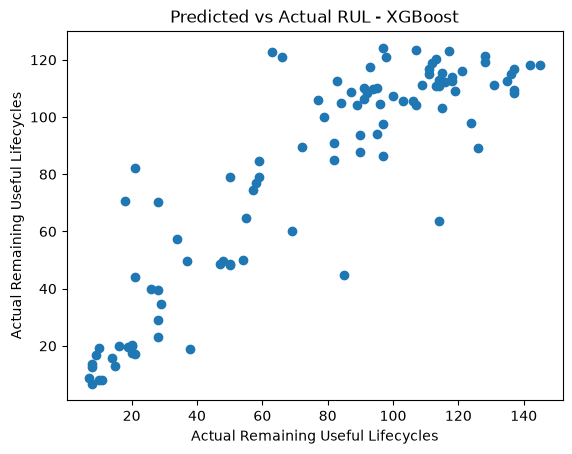

In [157]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_test_predictions)
plt.title("Predicted vs Actual RUL - XGBoost")
plt.xlabel("Actual Remaining Useful Lifecycles")
plt.ylabel("Actual Remaining Useful Lifecycles")
plt.show()

### 7. Feature importances

In [161]:
num_features = model.feature_importances_.shape[0]
num_features

58

In [163]:
X_test.columns

Index(['op1', 'op2', 'op3', 'sensor2', 'sensor3', 'sensor4', 'sensor7',
       'sensor9', 'sensor11', 'sensor12', 'sensor14', 'sensor17', 'sensor20',
       'sensor21', 'sensor2_mean5', 'sensor2_std5', 'sensor2_mean10',
       'sensor2_std10', 'sensor3_mean5', 'sensor3_std5', 'sensor3_mean10',
       'sensor3_std10', 'sensor4_mean5', 'sensor4_std5', 'sensor4_mean10',
       'sensor4_std10', 'sensor7_mean5', 'sensor7_std5', 'sensor7_mean10',
       'sensor7_std10', 'sensor9_mean5', 'sensor9_std5', 'sensor9_mean10',
       'sensor9_std10', 'sensor11_mean5', 'sensor11_std5', 'sensor11_mean10',
       'sensor11_std10', 'sensor12_mean5', 'sensor12_std5', 'sensor12_mean10',
       'sensor12_std10', 'sensor14_mean5', 'sensor14_std5', 'sensor14_mean10',
       'sensor14_std10', 'sensor17_mean5', 'sensor17_std5', 'sensor17_mean10',
       'sensor17_std10', 'sensor20_mean5', 'sensor20_std5', 'sensor20_mean10',
       'sensor20_std10', 'sensor21_mean5', 'sensor21_std5', 'sensor21_mean10',
       

In [212]:
features = pd.DataFrame(model.feature_importances_, index=testing_cols)[0]

In [213]:
all_features = features.sort_values(ascending=False)

In [214]:
all_features

sensor4_mean10     0.275593
sensor4_mean5      0.240865
sensor11_mean5     0.066930
sensor3_mean10     0.063696
sensor11_mean10    0.061959
sensor2_mean10     0.052551
sensor9_mean5      0.027128
sensor9_mean10     0.020738
sensor3_mean5      0.019938
sensor21_mean5     0.019378
sensor21_mean10    0.016286
sensor2_mean5      0.014225
sensor20_mean10    0.012394
sensor20_mean5     0.008673
sensor12_mean5     0.007671
sensor17_mean10    0.006441
sensor7_mean5      0.005402
sensor14_mean10    0.005393
sensor12           0.005072
sensor20           0.004947
sensor9            0.004399
sensor11           0.004122
sensor14_mean5     0.003978
sensor17_mean5     0.003740
sensor7_mean10     0.003408
sensor12_mean10    0.003261
sensor4            0.002947
sensor7            0.002572
sensor14           0.002206
sensor9_std10      0.001968
sensor2            0.001939
sensor7_std10      0.001911
sensor9_std5       0.001682
sensor14_std10     0.001637
sensor17_std10     0.001586
sensor4_std10      0

In [216]:
data = features.to_dict()

In [217]:
data

{'op1': 0.0006908386130817235,
 'op2': 0.0008291885023936629,
 'op3': 0.0,
 'sensor2': 0.001938766916282475,
 'sensor3': 0.001043408177793026,
 'sensor4': 0.002947036409750581,
 'sensor7': 0.002572043566033244,
 'sensor9': 0.004398696590214968,
 'sensor11': 0.004122285172343254,
 'sensor12': 0.005072018597275019,
 'sensor14': 0.0022060079500079155,
 'sensor17': 0.0,
 'sensor20': 0.004946561995893717,
 'sensor21': 0.0009190632845275104,
 'sensor2_mean5': 0.01422476302832365,
 'sensor2_std5': 0.0009824750013649464,
 'sensor2_mean10': 0.05255080386996269,
 'sensor2_std10': 0.001398807973600924,
 'sensor3_mean5': 0.019938362762331963,
 'sensor3_std5': 0.0009193269070237875,
 'sensor3_mean10': 0.06369644403457642,
 'sensor3_std10': 0.0014775518793612719,
 'sensor4_mean5': 0.24086514115333557,
 'sensor4_std5': 0.00081334647256881,
 'sensor4_mean10': 0.27559274435043335,
 'sensor4_std10': 0.0015701301163062453,
 'sensor7_mean5': 0.0054016560316085815,
 'sensor7_std5': 0.0013264515437185764,
 

In [247]:
top_20 = all_features.head(20)

In [256]:
top_20

sensor4_mean10     0.275593
sensor4_mean5      0.240865
sensor11_mean5     0.066930
sensor3_mean10     0.063696
sensor11_mean10    0.061959
sensor2_mean10     0.052551
sensor9_mean5      0.027128
sensor9_mean10     0.020738
sensor3_mean5      0.019938
sensor21_mean5     0.019378
sensor21_mean10    0.016286
sensor2_mean5      0.014225
sensor20_mean10    0.012394
sensor20_mean5     0.008673
sensor12_mean5     0.007671
sensor17_mean10    0.006441
sensor7_mean5      0.005402
sensor14_mean10    0.005393
sensor12           0.005072
sensor20           0.004947
Name: 0, dtype: float32

In [ ]:
# High Pressure Compressor (HPC) outlet temperature proved to be the most important feature in predicting RULs for turbofan engines

# Sensor 11 - Static pressure at HPC outlet
# Sensor 3 - Low Pressure Compressor (LPC) outlet net temperature
# Sensor 2 - Fan Outlet net temperature -- temperature after passing through the fan
# Sensor 9 - Physical engine core speed (RPM)

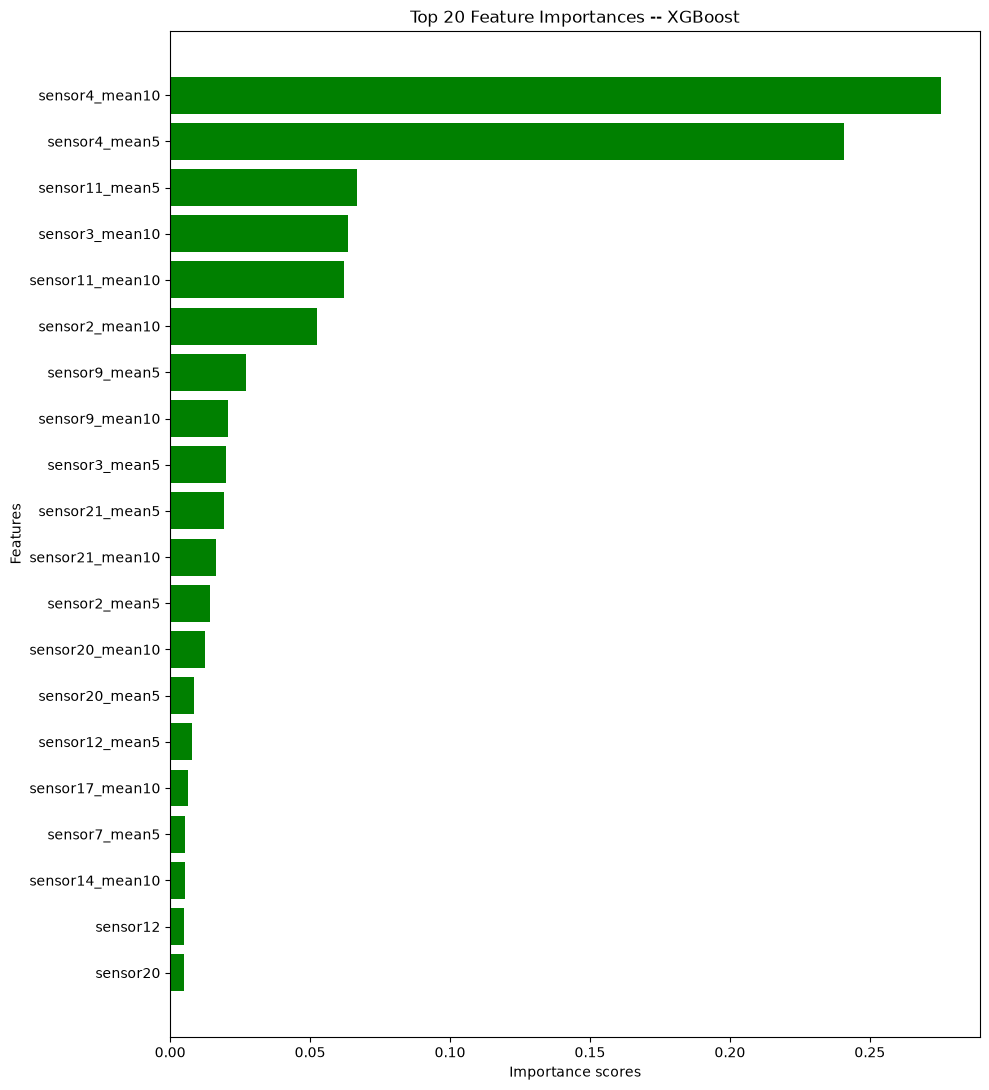

In [257]:
features = top_20.keys().tolist()
importance_scores = top_20.values.tolist()

type(features), type(importance_scores)

fig = plt.figure(figsize=(10, 11))

plt.barh(features, importance_scores, color='g')
plt.gca().invert_yaxis()
plt.xlabel("Importance scores")
plt.ylabel("Features")
plt.title("Top 20 Feature Importances -- XGBoost")
plt.tight_layout()
plt.show()

### 8. Save the model

In [258]:
model.save_model('../models/xgboost_model.json')